Upload the dataset to Colab

In [ ]:
from google.colab import files
uploaded = files.upload()   # choose letter-recognition.data when prompted

Saving letter-recognition.data to letter-recognition.data


Import libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
%matplotlib inline
sns.set(color_codes=True)

Load the dataset

In [ ]:
columns = ["lettr", "x-box", "y-box", "width", "high", "onpix",
           "x-bar", "y-bar", "x2bar", "y2bar", "xybar", "x2ybr",
           "xy2br", "x-ege", "xegvy", "y-ege", "yegvx"]

df = pd.read_csv("letter-recognition.data", header=None, names=columns)
df.head()

,lettr,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


Initial exploration

In [ ]:
print("Shape:", df.shape)
display(df.head())
display(df.tail())
df.dtypes

Shape: (20000, 17)


,lettr,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


,lettr,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
19995,D,2,2,3,3,2,7,7,7,6,6,6,4,2,8,3,7
19996,C,7,10,8,8,4,4,8,6,9,12,9,13,2,9,3,7
19997,T,6,9,6,7,5,6,11,3,7,11,9,5,2,12,2,4
19998,S,2,3,4,2,1,8,7,2,6,10,6,8,1,9,5,8
19999,A,4,9,6,6,2,9,5,3,1,8,1,8,2,7,2,8


,0
lettr,object
x-box,int64
y-box,int64
width,int64
high,int64
onpix,int64
x-bar,int64
y-bar,int64
x2bar,int64
y2bar,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   lettr   20000 non-null  object
 1   x-box   20000 non-null  int64 
 2   y-box   20000 non-null  int64 
 3   width   20000 non-null  int64 
 4   high    20000 non-null  int64 
 5   onpix   20000 non-null  int64 
 6   x-bar   20000 non-null  int64 
 7   y-bar   20000 non-null  int64 
 8   x2bar   20000 non-null  int64 
 9   y2bar   20000 non-null  int64 
 10  xybar   20000 non-null  int64 
 11  x2ybr   20000 non-null  int64 
 12  xy2br   20000 non-null  int64 
 13  x-ege   20000 non-null  int64 
 14  xegvy   20000 non-null  int64 
 15  y-ege   20000 non-null  int64 
 16  yegvx   20000 non-null  int64 
dtypes: int64(16), object(1)
memory usage: 2.6+ MB


In [ ]:
df.describe()

,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
count,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,4.023550,7.035500,5.121850,5.37245,3.505850,6.897600,7.500450,4.628600,5.178650,8.282050,6.45400,7.929000,3.046100,8.338850,3.691750,7.80120
std,1.913212,3.304555,2.014573,2.26139,2.190458,2.026035,2.325354,2.699968,2.380823,2.488475,2.63107,2.080619,2.332541,1.546722,2.567073,1.61747
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,3.000000,5.000000,4.000000,4.00000,2.000000,6.000000,6.000000,3.000000,4.000000,7.000000,5.00000,7.000000,1.000000,8.000000,2.000000,7.00000
50%,4.000000,7.000000,5.000000,6.00000,3.000000,7.000000,7.000000,4.000000,5.000000,8.000000,6.00000,8.000000,3.000000,8.000000,3.000000,8.00000
75%,5.000000,9.000000,6.000000,7.00000,5.000000,8.000000,9.000000,6.000000,7.000000,10.000000,8.00000,9.000000,4.000000,9.000000,5.000000,9.00000
max,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.00000


Check for missing values and duplicates

In [ ]:
print("Missing values per column:\n", df.isnull().sum())
print("\nTotal duplicate rows:", df.duplicated().sum())

Missing values per column:
 lettr    0
x-box    0
y-box    0
width    0
high     0
onpix    0
x-bar    0
y-bar    0
x2bar    0
y2bar    0
xybar    0
x2ybr    0
xy2br    0
x-ege    0
xegvy    0
y-ege    0
yegvx    0
dtype: int64

Total duplicate rows: 1332


Remove the duplicate rows

In [ ]:
print("Shape before removing duplicates:", df.shape)
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape before removing duplicates: (20000, 17)
Shape after removing duplicates: (18668, 17)


EDA: class distribution:

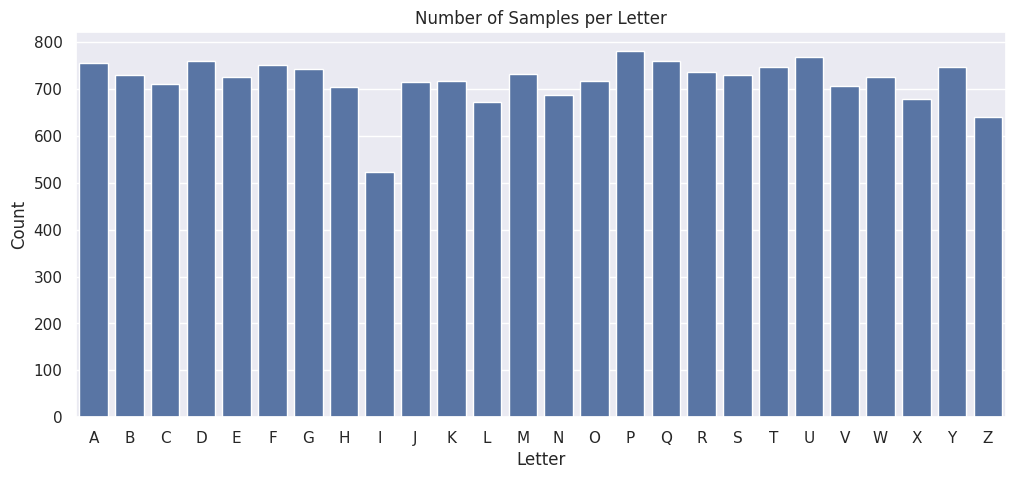

In [ ]:
plt.figure(figsize=(12,5))
sns.countplot(x='lettr', data=df, order=sorted(df['lettr'].unique()))
plt.title("Number of Samples per Letter")
plt.xlabel("Letter")
plt.ylabel("Count")
plt.show()

correlation heatmap:

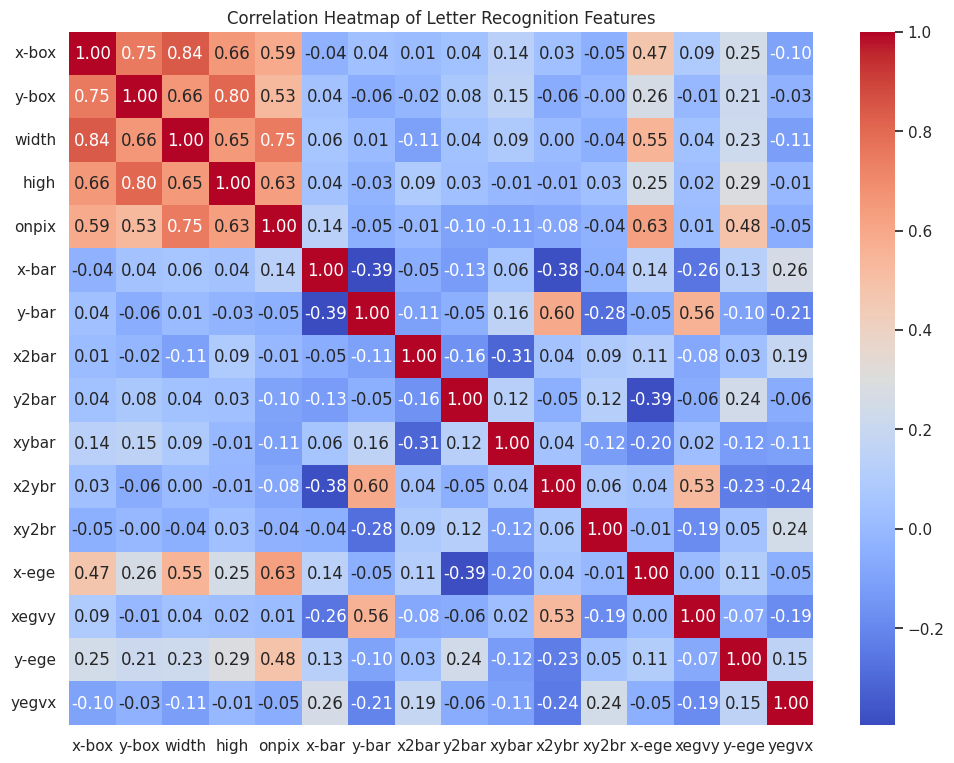

In [ ]:
plt.figure(figsize=(12,9))
corr_matrix = df.drop(columns=['lettr']).corr()
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Letter Recognition Features")
plt.show()

Encode the categorical variable (the target letter):

In [ ]:
le = LabelEncoder()
df['lettr_encoded'] = le.fit_transform(df['lettr'])

# Show mapping
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)
df[['lettr', 'lettr_encoded']].head()

{'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3), 'E': np.int64(4), 'F': np.int64(5), 'G': np.int64(6), 'H': np.int64(7), 'I': np.int64(8), 'J': np.int64(9), 'K': np.int64(10), 'L': np.int64(11), 'M': np.int64(12), 'N': np.int64(13), 'O': np.int64(14), 'P': np.int64(15), 'Q': np.int64(16), 'R': np.int64(17), 'S': np.int64(18), 'T': np.int64(19), 'U': np.int64(20), 'V': np.int64(21), 'W': np.int64(22), 'X': np.int64(23), 'Y': np.int64(24), 'Z': np.int64(25)}


,lettr,lettr_encoded
0,T,19
1,I,8
2,D,3
3,N,13
4,G,6


outlier detection

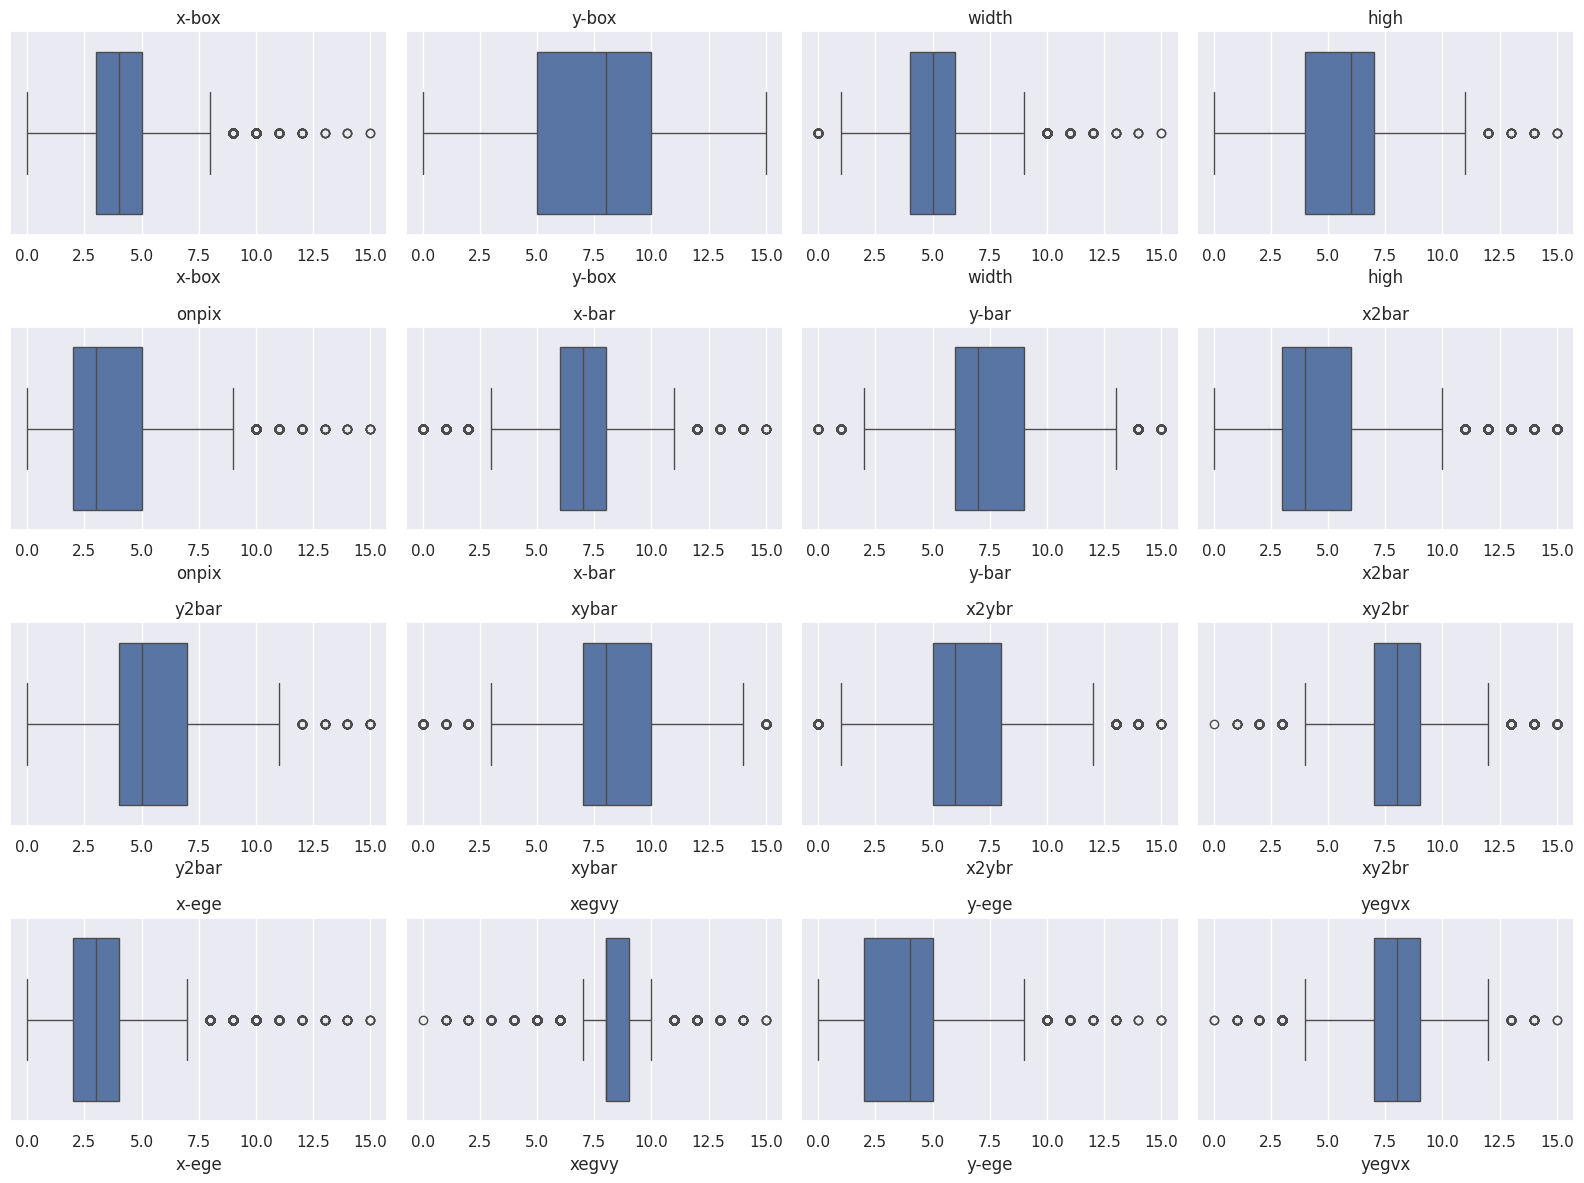

In [ ]:
feature_cols = columns[1:]  # all except 'lettr'

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, col in zip(axes.flatten(), feature_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

calculate and apply the IQR rule:

In [ ]:
Q1 = df[feature_cols].quantile(0.25)
Q3 = df[feature_cols].quantile(0.75)
IQR = Q3 - Q1

condition = ~((df[feature_cols] < (Q1 - 1.5 * IQR)) | (df[feature_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
df_no_outliers = df[condition]

print("Original shape:", df.shape)
print("Shape after outlier removal:", df_no_outliers.shape)
print(f"Rows removed: {df.shape[0] - df_no_outliers.shape[0]}")

Original shape: (18668, 18)
Shape after outlier removal: (11228, 18)
Rows removed: 7440


Report the outlier count

In [ ]:
print(f"Rows with at least one outlier feature: {df.shape[0] - df_no_outliers.shape[0]} "
      f"({(df.shape[0] - df_no_outliers.shape[0]) / df.shape[0] * 100:.1f}%)")

# Per-feature outlier counts, for more useful reporting
outlier_counts = ((df[feature_cols] < (Q1 - 1.5 * IQR)) | (df[feature_cols] > (Q3 + 1.5 * IQR))).sum()
print("\nOutliers per feature:\n", outlier_counts.sort_values(ascending=False))

Rows with at least one outlier feature: 7440 (39.9%)

Outliers per feature:
 xegvy    3881
x-ege    1089
xy2br     914
x-bar     733
x2bar     596
x-box     482
x2ybr     458
width     427
y-bar     341
xybar     331
onpix     292
y-ege     258
yegvx     243
y2bar     104
high       60
y-box       0
dtype: int64
